# Radial Density
Radial density defined as $\rho(r) = \langle \Psi(r')| \delta(r - r') | \Psi(r')\rangle$, assuming the state is properly normalized. Let $\hat{\rho}(r) = \delta(r-r')$. In our case the density comes out to be $\rho(r)= u(r)^2$. In more complicated systems, the result is more complicated. Notably, the $\delta(r - r')$ is not something that can be complex-rotated in a traditional sense. It's a distribution, and it definitely doesn't behave in the well-defined way that most observables do (the conditions that allow $(\psi_\theta | O_\theta | \psi_\theta)$ to be constant in $\theta$). As such, there's not really a well-defined way to define the rotated version of $\delta(r - r')$. Instead, we can define an operator $\rho_\theta(r) = (\psi_\theta|\delta(r-r')|\psi_\theta)/(\psi_\theta|\psi_\theta)$. I.e., we don't attempt to rotate the Dirac delta. This expression is of course $\theta$-dependent, and so the goal would be to compute it at $\theta=0$. As such, we need to involve back-rotation. 

In our case, 
$$
\rho_\theta(r) = \frac{(\psi_\theta|\delta(r-r')|\psi_\theta)}{(\psi_\theta|\psi_\theta)} = \frac{\Gamma e^{i\theta}u_\theta(r)^2}{ \Gamma e^{i\theta}\int\;dr\; u_\theta(r)^2} = u_\theta(r)^2,
$$
assuming the state is properly c-normalized. This varies with $\theta$, but the interior stays nearly constant. The $e^{i\theta}$ factor comes from the $e^{3i\theta/2}$ factor in the 3D complex scaling operation $\Psi_\theta(r) = U_\theta\Psi(r) = e^{i3\theta/2}\Psi(re^{i\theta})$.
## Backrotated Density
The back-rotated density is just $\rho^{\text{back}}(r) = u_0(r)^2 =  u_\theta(re^{-i\theta})^2$ because the back-rotated wavefunction is just the original Gamow state. Casting this with respect to the psuedo-rotated density:

$$
\rho_{\theta, BR}(r) = \rho_\theta(re^{-i\theta}),
$$

where $u_0$ is the Gamow state. One can alternatively show this with a similar integral argument that justified $\rho_\theta$ by back-rotating the resonance wavefunction: $\Psi_{\theta,BR}(r) = e^{-i3\theta/2}\frac{u_\theta(e^{-i\theta}r)}{e^{-i\theta}r}$ to recover the Gamow state, then computing the density with the standard delta function.

In [22]:
from src.ecensemble import ECEnsemble
from src.ec import ECSystem, TakagiRegularization
from src.dvr import DVR
from src.tikhonov import Tikhonov
from src.utils import *

import numpy as np
from numpy import pi, exp, sqrt
import random
import matplotlib.pyplot as plt
import pandas as pd

import logging
logging.basicConfig(level=logging.WARNING, format="[%(levelname)s] %(name)s: %(message)s")
logging.getLogger("matplotlib").setLevel(logging.WARNING)

In [23]:
save_plots = False
plots_folder = get_plots_path() / "ec_backrotated_density_wstats"
plots_folder.mkdir(exist_ok=True, parents=True)

In [24]:
# define system parameters
n = 256                      # number of DVR grid points
phi = pi / 24                # rotation angle
real_res = 1.606 - 1j*0.047  # expected value of resonance
L = 50.0                     # system size

def gauss_s(r):
    return 2.0 * exp(-((r-3.0)/1.5)**2) # potential

In [25]:
x_plot = np.linspace(0.0, L, 500)

### Explicitly back-rotating the complex-scaled resonance.
Here, we compute the complex-scaled resonance at $\phi=\pi/24$ and attempt to explicitly back-rotate to $\phi=0$ by evaluating
the wavefunction at $r\exp(-i\phi)$. Theoretically, this would recover the Gamow state, and we could use standard regularization techniques to compute observables. Computationally, it produces nonsense: we're attempting to recover a divergence, so any slight numerical noise explodes during the operation. 

In [26]:
# resonance wavefunction at phi=pi/24
test_system = DVR(n, L, rotation_angle=phi, potential=gauss_s)
_, eigstate = test_system.closest_to_resonance(real_res)
eigstate = eigstate[:, 0]

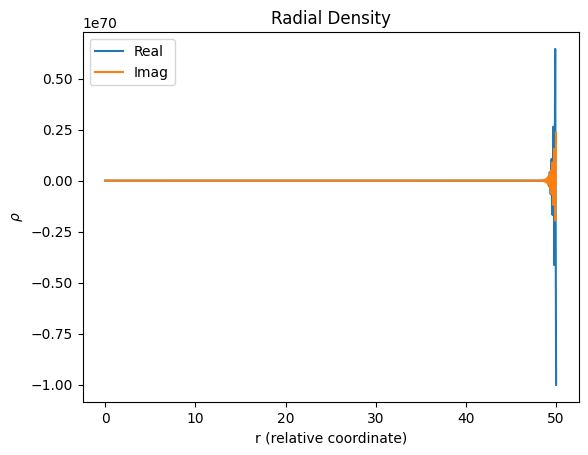

In [27]:
# compute density
radial_density = test_system.DVR_to_position_space(eigstate, x_plot*exp(-1j*phi))**2

fig, ax = plt.subplots()
ax.plot(x_plot, np.real(radial_density), label='Real')
ax.plot(x_plot, np.imag(radial_density), label='Imag')
ax.set_xlabel("r (relative coordinate)")
ax.set_ylabel(r"$\rho$")
ax.set_title(r"Radial Density")
ax.legend()
if save_plots:
    plt.savefig(plots_folder / "CS_radial_density.png")
plt.show()

### Computing the back-rotated resonance with EC
Here, we use EC trained on complex-scaled resonance eigenstates to predict the resonant state at $\phi=0$; i.e., we use EC to back-rotate the resonance, rather than attempting to do it analytically. We then compute the density of the back-rotated state.

In [28]:
# EC back-rotation
phi_train = np.linspace(pi/24, pi/6, 50)

test_EC = ECSystem(test_system, real_res)
test_EC.train(phi_train)
test_EC.construct_basis()

ec_density = test_EC.predict_density_at(0.0, x_plot)

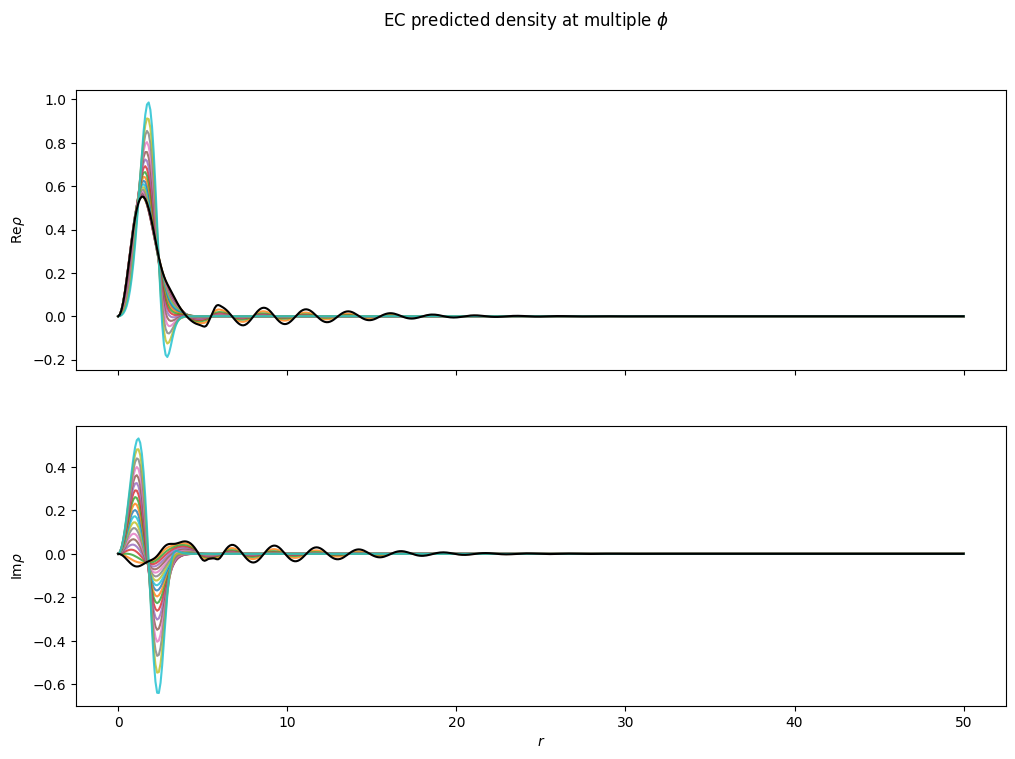

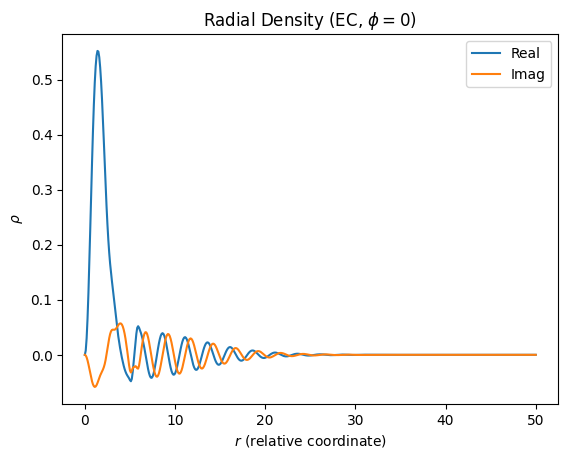

In [29]:
# a visualization to show that the radial density isn't correct just because
# EC produces something that barely changes in phi.
# in `default_rr_backrotation.ipynb`, we compute (psi_theta | r^2 | psi_theta),
# where r^2 is unrotated, and this supports this: the expectation value changes 
# rapidly until it converges the on the correct value at theta=0
# interestingly, once the angle is past the resonance pole angle, decreasing theta
# towards zero causes the wavefunction to shrink down to the correct value. 
# I'd expect the wavefunction to grow as we approach theta=0 (tending towards
# divergence despite never being able to get there).
temp_phi_range = np.linspace(0.0, pi/6, 20)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8), sharex=True)
for i, p in enumerate(temp_phi_range):
    ec_density_temp = test_EC.predict_density_at(p, x_plot)
    color = 'black' if i == 0 else f'C{i}'
    alpha = 1.0 if i == 0 else .8
    zorder = 800 if i == 0 else i
    ax1.plot(x_plot, np.real(ec_density_temp), alpha=alpha, zorder=zorder, color=color)#, label=f'{p}')
    ax2.plot(x_plot, np.imag(ec_density_temp), alpha=alpha, zorder=zorder, color=color)
ax2.set_xlabel(r"$r$")
ax1.set_ylabel(r"Re$\rho$")
ax2.set_ylabel(r"Im$\rho$")
fig.suptitle(r"EC predicted density at multiple $\phi$") 
plt.show()
    
fig, ax = plt.subplots()
ax.plot(x_plot, np.real(ec_density), label='Real')
ax.plot(x_plot, np.imag(ec_density), label='Imag')
ax.set_xlabel(r"$r$ (relative coordinate)")
ax.set_ylabel(r"$\rho$")
ax.set_title(r"Radial Density (EC, $\phi=0$)")
ax.legend()
if save_plots:
    plt.savefig(plots_folder / "ec_radial_density.png")
plt.show()

## Tikhonov Regularization
Here, we use Tikhonov regularization to compute the back-rotated density. For details, see `tikhonov_regtest.ipynb`. $\rho_{\theta,BR}(r) = \Gamma e^{2i\theta} \tilde{f}_\theta(x+i\theta)$, where $\tilde{f}_\theta(x) = u^2_\theta(r_0 e^{-x})$ where $x=-\log(r/r_0)$ and $r_0=1.0$.

In [30]:
# compute numerical FFT
tikhonov = Tikhonov(n, L)

# compute density on logmesh
r_log, u_on_logmesh =  tikhonov.dvrstate_on_logmesh(eigstate)
f = u_on_logmesh**2

# compute FFT
xis, f_hat = tikhonov.compute_fft(f)

# apply Tikhonov filter
tikhonov_density = tikhonov.apply_tikhonov_filter(phi, xis, f_hat, "high_pass")

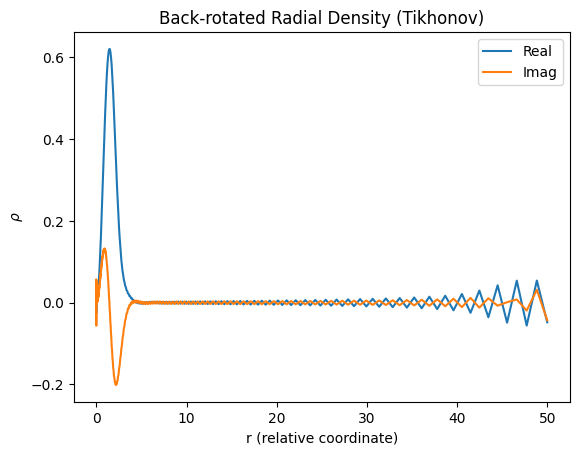

In [31]:
fig, ax = plt.subplots()
ax.plot(r_log, np.real(tikhonov_density), label='Real')
ax.plot(r_log, np.imag(tikhonov_density), label='Imag')
ax.set_xlabel("r (relative coordinate)")
ax.set_ylabel(r"$\rho$")
ax.set_title(r"Back-rotated Radial Density (Tikhonov)")
ax.legend()
if save_plots:
    plt.savefig(plots_folder / "tikhonov_radial_density.png")
plt.show()

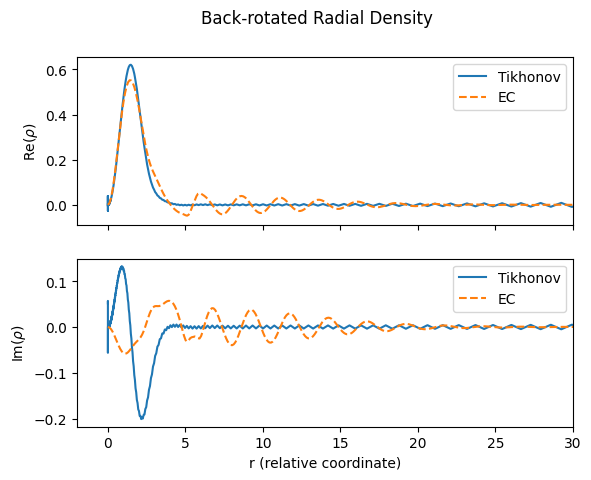

In [32]:
fig, (ax, ax1) = plt.subplots(2, 1, sharex=True)
ax.plot(r_log, np.real(tikhonov_density), label='Tikhonov')
ax.plot(x_plot, np.real(ec_density), '--', label='EC')
ax.set_ylabel(r"Re($\rho$)")

ax1.plot(r_log, np.imag(tikhonov_density), label='Tikhonov')
ax1.plot(x_plot, np.imag(ec_density), '--', label='EC')
ax1.set_ylabel(r"Im($\rho$)")
ax1.set_xlabel("r (relative coordinate)")
ax.legend()  

ax1.legend()
ax.set_xlim([-2, 30])
fig.suptitle(r"Back-rotated Radial Density")
if save_plots:
    plt.savefig(plots_folder / "tikhonov_ec_density_comparison.png")
plt.show()

## Tikhonov Regularization to find $\rho_\theta(r)$ at multiple non-zero $\phi$
Here, we use Tikhonov regularization to find the rotated density $\rho_\theta$ in a range of $\phi$. This is not the back-rotated density.

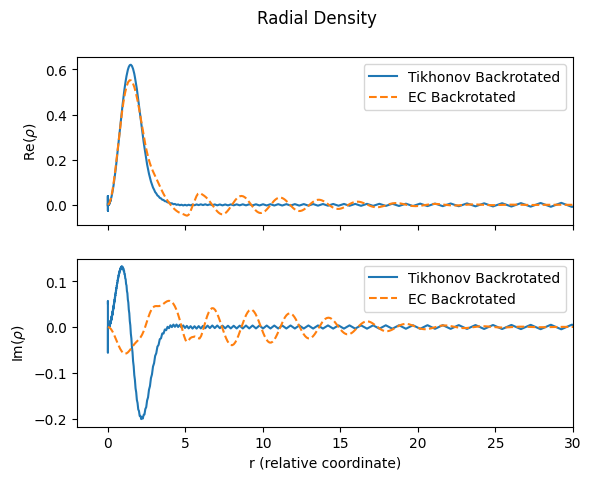

In [39]:
tikhonov_system = Tikhonov(n, L)

phis = np.linspace(pi/23, pi/7, 10)

fig, (ax, ax1) = plt.subplots(2, 1, sharex=True)

# plot envelope of curves for many phi (not the back-rotated density.)
real_us, imag_us = [], []
for phi in phis:
    test_system.reset_rotation_angle(phi)
    state = test_system.closest_to_resonance(real_res)[1][:, 0]
    # compute density on logmesh
    rs, u_on_logmesh =  tikhonov_system.dvrstate_on_logmesh(state)
    f = u_on_logmesh**2

    # compute FFT
    xis, f_hat = tikhonov_system.compute_fft(f)

    # apply Tikhonov filter
    t_d = tikhonov_system.apply_tikhonov_filter(phi, xis, f_hat, kappa=1e-6)
    real_us.append(np.real(t_d))
    imag_us.append(np.imag(t_d))

real_us = np.stack(real_us, axis=0)
imag_us = np.stack(imag_us, axis=0)

#ax.fill_between(r_log, real_us.min(axis=0), real_us.max(axis=0), alpha=0.3, label="CS Density (Tikhonov)")
#ax1.fill_between(r_log, imag_us.min(axis=0), imag_us.max(axis=0), alpha=0.3, label="CS Density (Tikhonov)")

# plot median curve
#ax.plot(r_log, np.median(real_us, axis=0), lw=1, alpha=1.0, color='black', label='Median CS Density (Tikhonov)')
#ax1.plot(r_log, np.median(imag_us, axis=0), lw=1, alpha=1.0, color='black', label='Median CS Density (Tikhonov)')

ax.plot(r_log, np.real(tikhonov_density), label='Tikhonov Backrotated')
ax.plot(x_plot, np.real(ec_density), '--', label='EC Backrotated')
ax1.plot(r_log, np.imag(tikhonov_density), label='Tikhonov Backrotated')
ax1.plot(x_plot, np.imag(ec_density), '--', label='EC Backrotated')

ax.set_ylabel(r"Re($\rho$)")
ax1.set_ylabel(r"Im($\rho$)")
ax1.set_xlabel("r (relative coordinate)")
ax.legend() 
ax1.legend()
ax.set_xlim([-2, 30])
fig.suptitle(r"Radial Density")
if save_plots:
    plt.savefig(plots_folder / "tikhonov_ec_density_comparison_wTikhonovCSband.png")
plt.show()

## EC to find $\rho_\theta(r)$ at multiple non-zero $\phi$
Here, we use EC to find the rotated density $\rho_\theta$ in a range of non-zero $\phi$. This is not the back-rotated density.

This also fails for the same reason that Tikhonov was introduced. EC gives us the complex-scaled resonance at $\phi$. The rotated density operator at $\phi$ is still evaluated at $u_\theta(re^{-i\theta})$. So, even though this is analytically fine, small errors will still blow up (we end up having to "reference" the back-rotated wavefunction). Tikhonov only still works because it blindly cuts off all UV modes and thereby also cuts off errors. At $\phi=0$, things are different: EC gives us the back-rotated wavefunction at $\phi=0$, with all of the regulated information already present. So, the density is just evaluated with $\theta=0$: $\rho_{\theta=0,BR} = \Gamma u_{\theta=0}(r)^2$.

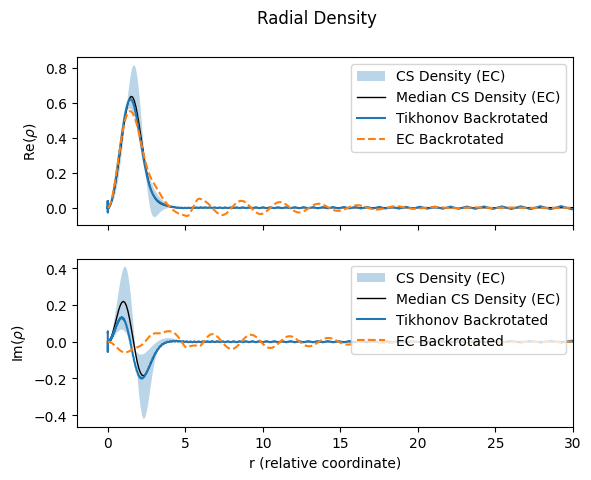

In [34]:
phis = np.linspace(pi/23, pi/7, 10)
fig, (ax, ax1) = plt.subplots(2, 1, sharex=True)
# plot envelope of curves for many phi
real_us, imag_us = [], []
for phi in phis:
    rhos = test_EC.predict_density_at(phi, x_plot)
    real_us.append(np.real(rhos))
    imag_us.append(np.imag(rhos))

real_us = np.stack(real_us, axis=0)
imag_us = np.stack(imag_us, axis=0)

ax.fill_between(x_plot, np.min(real_us, axis=0), np.max(real_us, axis=0), alpha=0.3, label="CS Density (EC)")
ax1.fill_between(x_plot, np.min(imag_us, axis=0), np.max(imag_us, axis=0), alpha=0.3, label="CS Density (EC)")

# plot median curve
ax.plot(x_plot, np.median(real_us, axis=0), lw=1, alpha=1.0, color='black', label='Median CS Density (EC)')
ax1.plot(x_plot, np.median(imag_us, axis=0), lw=1, alpha=1.0, color='black', label='Median CS Density (EC)')

ax.plot(r_log, np.real(tikhonov_density), label='Tikhonov Backrotated')
ax.plot(x_plot, np.real(ec_density), '--', label='EC Backrotated')
ax1.plot(r_log, np.imag(tikhonov_density), label='Tikhonov Backrotated')
ax1.plot(x_plot, np.imag(ec_density), '--', label='EC Backrotated')

ax.set_ylabel(r"Re($\rho$)")
ax1.set_ylabel(r"Im($\rho$)")
ax1.set_xlabel("r (relative coordinate)")
ax.legend() 
ax1.legend()
ax.set_xlim([-2, 30])
fig.suptitle(r"Radial Density")
if save_plots:
    plt.savefig(plots_folder / "tikhonov_ec_density_comparison_wECCSband.png")
plt.show()

## EC Back-rotated Density w/ Stats
Using multiple EC systems to compute the back-rotated density and computing stats for where the range will likely fall.

In [14]:
import random

seed = 1
random.seed(seed)
np.random.seed(seed)

In [44]:
# number of EC systems
n_ecsystems = 128
n = 256
L = 50.0
phi_predict = 0.0

# training region
phi_training_range, num_phi_points = [pi/24, pi/6], 20

# construct EC ensemble and train all ECs
EC_ensemble = ECEnsemble(n_ecsystems, test_system, real_res)
EC_ensemble.train(phi_training_range, num_phi_points)
EC_ensemble.construct_bases()

med, err68, err95 = EC_ensemble.predict_density_stats(phi_predict, x_plot)

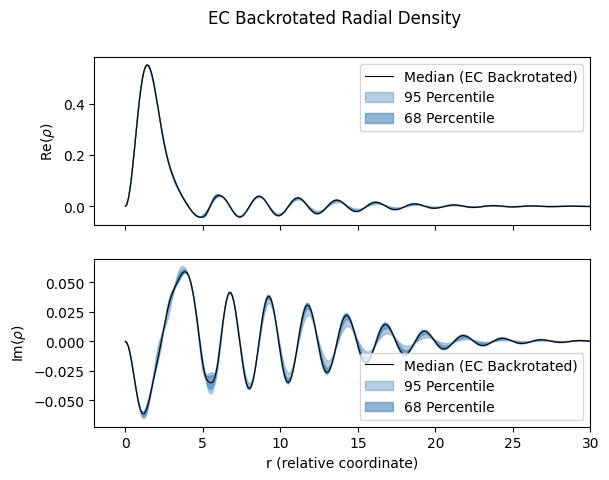

In [46]:
fig, (ax, ax1) = plt.subplots(2, 1, sharex=True)
ax.plot(x_plot, np.real(med), label='Median (EC Backrotated)', linewidth=0.8, alpha=1.0, color='black')
ax.fill_between(x_plot, np.real(med) - np.real(err95[0,:]),
                np.real(err95[1,:]) + np.real(med), alpha=0.4, color='steelblue', label="95 Percentile")
ax.fill_between(x_plot, np.real(med) - np.real(err68[0,:]),
                np.real(err68[1,:]) + np.real(med), alpha=0.6, color='steelblue', label="68 Percentile")

ax1.plot(x_plot, np.imag(med), label='Median (EC Backrotated)', linewidth=0.8, alpha=1.0, color='black')
ax1.fill_between(x_plot, np.imag(med) - np.imag(err95[0,:]),
                         np.imag(med) + np.imag(err95[1,:]), alpha=0.4, color='steelblue', label="95 Percentile")
ax1.fill_between(x_plot, np.imag(med) - np.imag(err68[0, :]), 
                         np.imag(med) + np.imag(err68[1, :]), alpha=0.6, color='steelblue', label="68 Percentile")

ax.set_ylabel(r"Re($\rho$)")
ax1.set_ylabel(r"Im($\rho$)")
ax1.set_xlabel("r (relative coordinate)")
ax.legend() 
ax1.legend()
ax.set_xlim([-2, 30])
fig.suptitle(r"EC Backrotated Radial Density")
if save_plots:
    plt.savefig(plots_folder / "ec_backrotate_density_wstats.png")
plt.show()

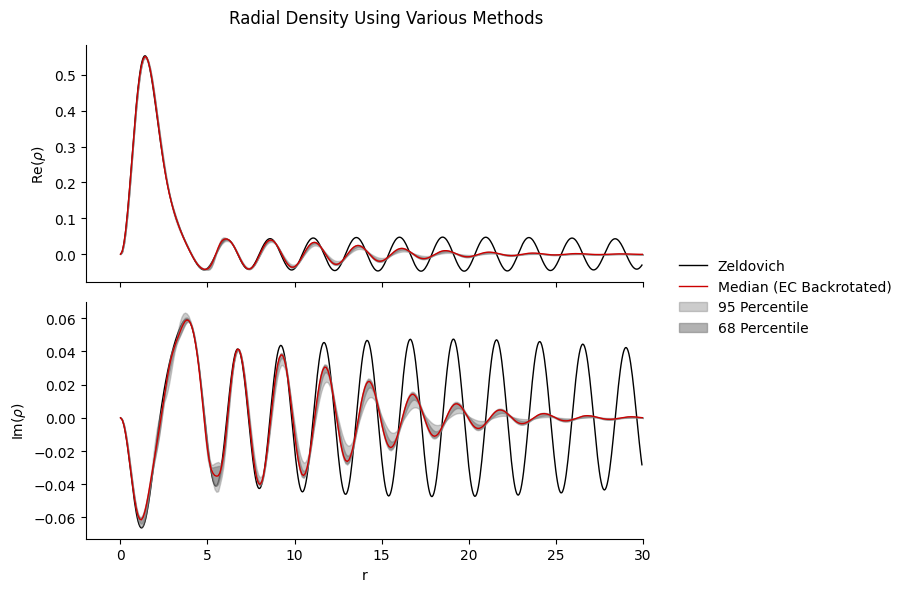

In [47]:
# create colors to match presentation
ncsured = '#CC0000'
streamlineblue = '#003087'

# Load Mathematica Zeldovich data
mma = np.loadtxt("../data/zeldovich_density.csv", delimiter=",")
r_mma = mma[:, 0]
rho_re_mma = mma[:, 1]
rho_im_mma = mma[:, 2]

# Load Mathematica CSM data (not plotted right now)
"""
mma = np.loadtxt("../data/mathematica_csm_density.csv", delimiter=",")
r_mma_cs = mma[:, 0]
rho_re_mma_cs = mma[:, 1]
rho_im_mma_cs = mma[:, 2]
"""

# python EC density from above (med)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# plot zeldovich ground truth
ax1.plot(r_mma, rho_re_mma, label='Zeldovich', linewidth=1., zorder=0, color='black')
ax2.plot(r_mma, rho_im_mma, label='Zeldovich', linewidth=1., zorder=0, color='black')

# plot tikhonov backrotation
#ax1.plot(r_log, np.real(tikhonov_density), '--', linewidth=1.0, zorder=1, label='Tikhonov Backrotated',  color=streamlineblue)
#ax2.plot(r_log, np.imag(tikhonov_density), '--', linewidth=1.0, zorder=1, label='Tikhonov Backrotated',  color=streamlineblue)

# plot EC back rotation with error bands
ax1.plot(x_plot, np.real(med), label='Median (EC Backrotated)', linewidth=1.0, zorder=3, alpha=1.0, color=ncsured)
ax1.fill_between(x_plot, np.real(med) - np.real(err95[0,:]),
                np.real(err95[1,:]) + np.real(med), alpha=0.4, zorder=2, color='gray', label="95 Percentile")
ax1.fill_between(x_plot, np.real(med) - np.real(err68[0,:]),
                np.real(err68[1,:]) + np.real(med), alpha=0.6, zorder=2, color='gray', label="68 Percentile")

ax2.plot(x_plot, np.imag(med), label='Median (EC Backrotated)', linewidth=1.0, zorder=3, alpha=1.0, color=ncsured)
ax2.fill_between(x_plot, np.imag(med) - np.imag(err95[0,:]),
                         np.imag(med) + np.imag(err95[1,:]), alpha=0.4, zorder=2, color='gray', label="95 Percentile")
ax2.fill_between(x_plot, np.imag(med) - np.imag(err68[0, :]), 
                         np.imag(med) + np.imag(err68[1, :]), alpha=0.6, zorder=2, color='gray', label="68 Percentile")


# plot mathematica complex scaling data (currently not plotting)
#ax1.plot(r_mma_cs, rho_re_mma_cs, '--', label='Mathematica CS', linewidth=0.5, color='red')
#ax2.plot(r_mma_cs, rho_im_mma_cs, '--', label='Mathematica CS', linewidth=0.8, color='red')

# set labels and limits
ax1.set_ylabel(r'Re($\rho$)')
ax2.set_xlabel('r')
ax2.set_ylabel(r'Im($\rho$)')
ax2.set_xlim([-2,30])

fig.suptitle("Radial Density Using Various Methods")

# remove spines
for ax in [ax1, ax2]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# get legend handles / labels from one axis
handles, labels = ax1.get_legend_handles_labels()
# create one legend for both axes
fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.85, 0.5),
    frameon=False
)
plt.tight_layout(rect=[0, 0, 0.85, 1])

if save_plots:
    plt.savefig(plots_folder / "density_comparison.png", bbox_inches='tight', transparent=True, dpi=600)
plt.show()

### EC back-rotated density for various number of sample points with stats

In [18]:
phi_training_range, num_phi_points_list = [pi/24, pi/6], [10, 15, 20, 30, 50]
EC_ensemble = ECEnsemble(n_ecsystems, test_system, real_res)

meds, err95s = [], []
for nphi in num_phi_points_list:
    print(f"Training with {nphi} sample points")
    # train ensemble with nphi # sample points
    EC_ensemble.train(phi_training_range, nphi)
    EC_ensemble.construct_bases()

    # grab back-rotated density
    med, _, err95 = EC_ensemble.predict_density_stats(phi_predict, x_plot)

    meds.append(med)
    err95s.append(err95)
    
    # clear model
    EC_ensemble.clear_all()

meds = np.array(meds)
err95s = np.array(err95s)

Training with 10 sample points
Training with 15 sample points
Training with 20 sample points
Training with 30 sample points
Training with 50 sample points


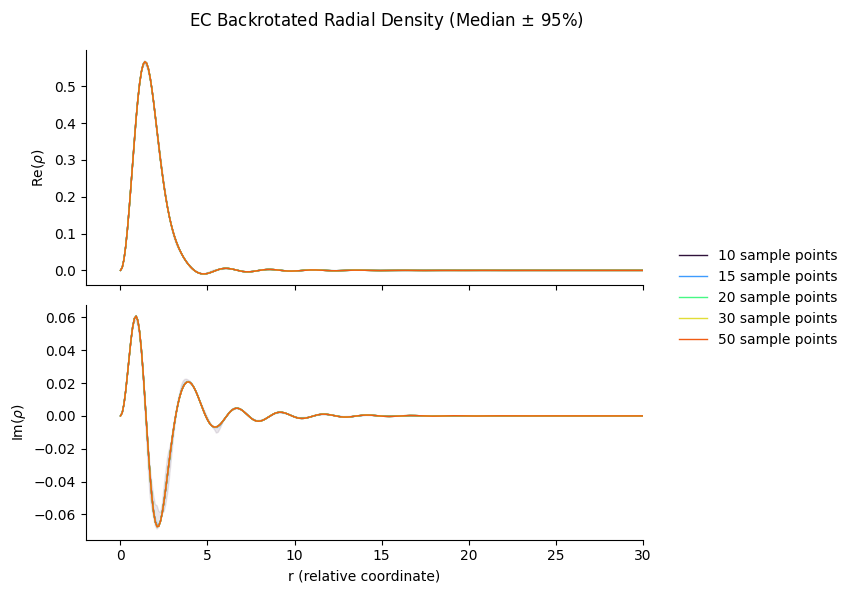

In [19]:
cmap = plt.get_cmap("turbo")
colors = [cmap(i / len(num_phi_points_list)) for i in range(len(num_phi_points_list))]
alphas = [0.1 + (0.5 - 0.12)*i / (len(num_phi_points_list)-1) for i in range(len(num_phi_points_list))]

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8,6))

cutoff = 0
for j, nphi in enumerate(num_phi_points_list[cutoff:]):
    i = j + cutoff
    # plot real density for each sample point set
    ax1.plot(x_plot, np.real(meds[i]), label=f'{nphi} sample points', linewidth=1.0, alpha=1.0, c=colors[i], zorder=3)
    ax1.fill_between(x_plot, np.real(meds[i]) - np.real(err95s[i, 0, :]),
                    np.real(err95s[i, 1, :]) + np.real(meds[i]), alpha=alphas[i], color=colors[i], zorder=2)

    # plot imag density for each sample point set
    ax2.plot(x_plot, np.imag(meds[i]), label=f'{nphi} sample points', linewidth=1.0, alpha=1.0, c=colors[i], zorder=3)
    ax2.fill_between(x_plot, np.imag(meds[i]) - np.imag(err95s[i, 0, :]),
                             np.imag(meds[i]) + np.imag(err95s[i, 1, :]), alpha=alphas[i], color=colors[i], zorder=2)

ax1.set_ylabel(r"Re($\rho$)")
ax2.set_ylabel(r"Im($\rho$)")
ax2.set_xlabel("r (relative coordinate)")
ax1.set_xlim([-2, 30])
fig.suptitle(r"EC Backrotated Radial Density (Median $\pm$ 95%)")

# remove top and right side spines
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
# get legend handles / labels from one axis
handles, labels = ax.get_legend_handles_labels()
# create one legend for both axes
fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.85, 0.5),
    frameon=False
)
plt.tight_layout(rect=[0, 0, .85, 1])

if save_plots:
    plt.savefig(plots_folder / "ec_backrotate_density_wstats_nsample.png", bbox_inches="tight", transparent=True, dpi=600)
plt.show()

### Plotting the EC back-rotated density for multiple values as it approaches $\phi\rightarrow 0$

In [50]:
phis = np.linspace(0.0, pi/6, 50)
densities = []
for phi in phis:
    density = test_EC.predict_density_at(phi, x_plot)
    densities.append(density)
densities=np.array(densities)

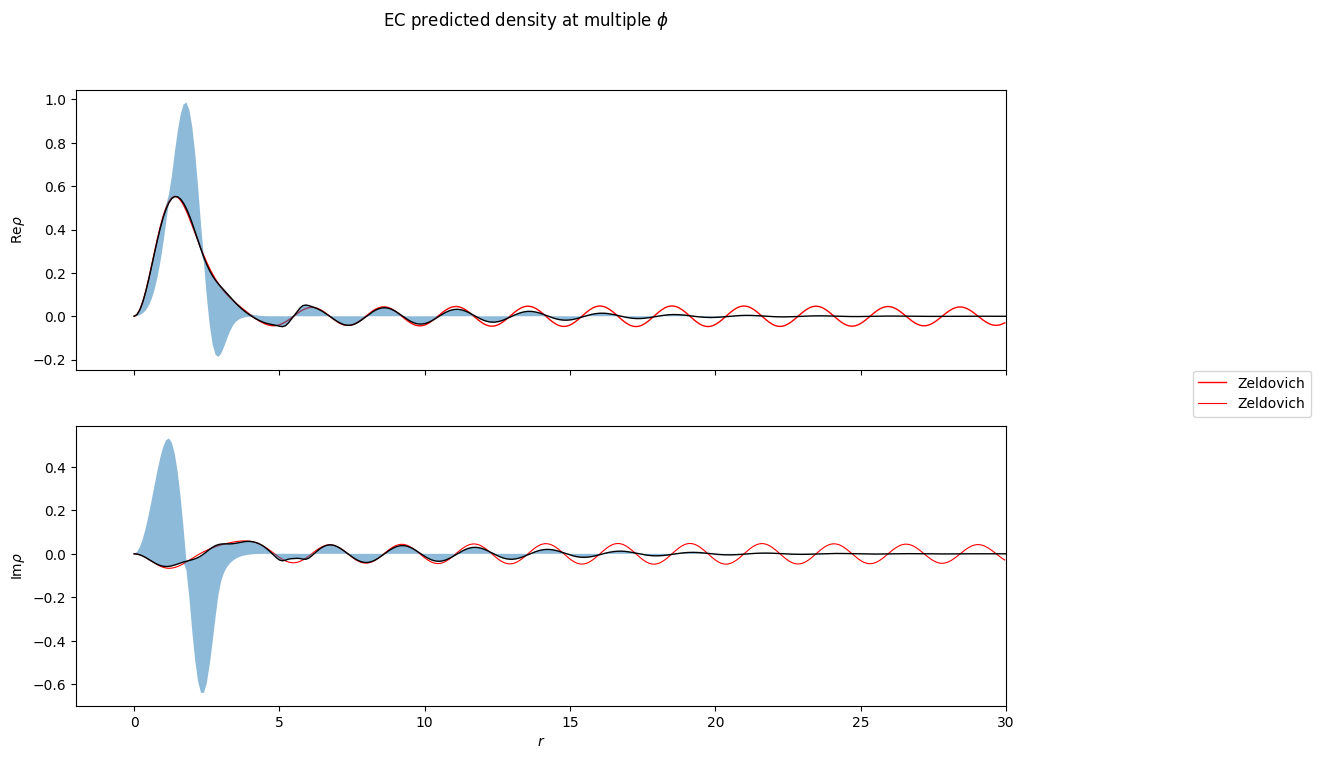

In [55]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8), sharex=True)
ax1.fill_between(x_plot, np.min(np.real(densities), axis=0), np.max(np.real(densities), axis=0), alpha=0.5)
ax2.fill_between(x_plot, np.min(np.imag(densities), axis=0), np.max(np.imag(densities), axis=0), alpha=0.5)
ax1.plot(x_plot, np.real(densities[0]), lw=1, color='black')
ax1.set_xlim([-2, 30])
ax2.set_xlim([-2, 30])
ax2.plot(x_plot, np.imag(densities[0]), lw=1, color='black')
ax2.set_xlabel(r"$r$")
ax1.set_ylabel(r"Re$\rho$")
ax2.set_ylabel(r"Im$\rho$")
ax1.plot(r_mma, rho_re_mma, label='Zeldovich', linewidth=1., zorder=0, color='red')
ax2.plot(r_mma, rho_im_mma, label='Zeldovich', linewidth=.8, zorder=0, color='red')
fig.legend(loc='center left', bbox_to_anchor=(1.05, .5))
fig.suptitle(r"EC predicted density at multiple $\phi$") 
plt.show()